In [ ]:
from pathlib import Path
import pandas as pd


pd.set_option("display.max_columns", None)

lpd = pd.read_csv(
    "../data/raw/LivingPlanetIndex_2024_PublicData/LPD_2024_public.csv"
)

year_columns = [str(year) for year in range(1950, 2021)]

existing_years = [
    col for col in year_columns
    if col in lpd.columns
]

len(existing_years), existing_years[:5], existing_years[-5:]

(71,
 ['1950', '1951', '1952', '1953', '1954'],
 ['2016', '2017', '2018', '2019', '2020'])

In [3]:
lpd_long = lpd.melt(
    id_vars=[
        "ID",
        "Binomial",
        "Class",
        "Region",
        "System",
        "Latitude",
        "Longitude"
    ],
    value_vars=existing_years,
    var_name="Year",
    value_name="Population"
)

lpd_long.head()

,ID,Binomial,Class,Region,System,Latitude,Longitude,Year,Population
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1950,NaN
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1950,NaN
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1950,NaN
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1950,NaN
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1950,NaN


In [4]:
lpd_long.shape

(2555716, 9)

In [5]:
lpd_long["Population"].isna().sum()

2135360

In [6]:
lpd_long = lpd_long.dropna(subset=["Population"]).copy()

lpd_long.shape

(420356, 9)

In [7]:
lpd_long["Year"] = lpd_long["Year"].astype(int)

lpd_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420356 entries, 81 to 2555713
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          420356 non-null  int64  
 1   Binomial    420356 non-null  object 
 2   Class       420356 non-null  object 
 3   Region      420356 non-null  object 
 4   System      420356 non-null  object 
 5   Latitude    420356 non-null  float64
 6   Longitude   420356 non-null  float64
 7   Year        420356 non-null  int64  
 8   Population  420356 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 32.1+ MB


In [8]:
population_summary = (
    lpd_long
    .sort_values(["ID", "Year"])
    .groupby("ID")
    .agg(
        Binomial=("Binomial", "first"),
        Class=("Class", "first"),
        Region=("Region", "first"),
        System=("System", "first"),
        Latitude=("Latitude", "first"),
        Longitude=("Longitude", "first"),
        First_Year=("Year", "min"),
        Last_Year=("Year", "max"),
        First_Population=("Population", "first"),
        Last_Population=("Population", "last")
    )
    .reset_index()
)

population_summary.head()

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0


In [9]:
population_summary["Years_Monitored"] = (
    population_summary["Last_Year"]
    - population_summary["First_Year"]
)

In [19]:
trend_data = population_summary[
    population_summary["Years_Monitored"] >= 10
].copy()

In [20]:
import numpy as np

trend_data["Log_Trend"] = (
    np.log1p(trend_data["Last_Population"])
    - np.log1p(trend_data["First_Population"])
)

In [21]:
trend_data["Log_Trend"].describe()

count    21284.000000
mean        -0.099888
std          1.674060
min        -12.763759
25%         -0.690656
50%          0.000000
75%          0.464595
max         21.671336
Name: Log_Trend, dtype: float64

In [22]:
trend_data.sort_values(
    "Log_Trend",
    ascending=False
).head(10)

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Years_Monitored,Trend,Log_Trend
15420,19326,Rhomboplites_aurorubens,Actinopteri,North America,Marine,31.19689,-78.440785,1950,2016,8020.0,2.070000e+13,66,2.581047e+09,21.671336
1674,1725,Larus_ridibundus,Aves,Europe,Marine,53.86444,8.606390,1950,1999,0.0,6.400000e+04,49,inf,11.066654
6503,7064,Anser_anser,Aves,Europe,Freshwater,41.83333,-5.616670,1969,1992,0.0,1.559000e+04,23,inf,9.654449
6801,7365,Phoenicopterus_roseus,Aves,Europe,Freshwater,37.11667,-4.783330,1972,2007,0.0,1.507600e+04,35,inf,9.620926
1664,1714,Larus_fuscus,Aves,Europe,Marine,53.86444,8.606390,1950,1999,1.0,2.900000e+04,49,2.899900e+04,9.581938
6803,7367,Phoenicopterus_roseus,Aves,Europe,Freshwater,39.22389,9.030830,1970,2007,0.0,1.425000e+04,37,inf,9.564582
4348,4900,Larus_audouinii,Aves,Europe,Marine,40.58611,0.702500,1979,1997,0.0,1.172500e+04,18,inf,9.369564
4027,4578,Oncorhynchus_tshawytscha,Actinopteri,North America,Freshwater,43.50000,-87.500000,1965,1988,0.0,9.900000e+03,23,inf,9.200391
1926,1981,Halichoerus_grypus,Mammalia,Europe,Marine,57.52500,-7.610000,1961,2001,0.0,9.216000e+03,40,inf,9.128805
1766,1819,Rissa_tridactyla,Aves,Europe,Marine,54.16667,7.883330,1950,1999,0.0,7.500000e+03,49,inf,8.922792


In [23]:
trend_data["Risk_Level"] = pd.cut(
    trend_data["Log_Trend"],
    bins=[
        -np.inf,
        -2,
        -1,
        -0.25,
        np.inf
    ],
    labels=[
        "Critical",
        "High",
        "Moderate",
        "Low"
    ]
)

In [24]:
trend_data.groupby(
    ["Class", "Risk_Level"]
).size()

Class           Risk_Level
Actinopteri     Critical       245
                High           423
                Moderate       776
                Low           3403
Amphibia        Critical        32
                High            37
                Moderate        36
                Low            100
Aves            Critical      1469
                High          1295
                Moderate      1936
                Low           7776
Dipneusti       Critical         1
                High             0
                Moderate         0
                Low              0
Elasmobranchii  Critical        16
                High            27
                Moderate        84
                Low            270
Holocephali     Critical         0
                High             0
                Moderate         0
                Low              4
Mammalia        Critical       168
                High           280
                Moderate       584
                Low         

In [25]:
population_summary["Log_Trend"] = (
    np.log1p(population_summary["Last_Population"])
    - np.log1p(population_summary["First_Population"])
)

trend_data = population_summary[
    population_summary["Years_Monitored"] >= 10
].copy()

trend_data["Log_Trend"].describe()

count    21284.000000
mean        -0.099888
std          1.674060
min        -12.763759
25%         -0.690656
50%          0.000000
75%          0.464595
max         21.671336
Name: Log_Trend, dtype: float64

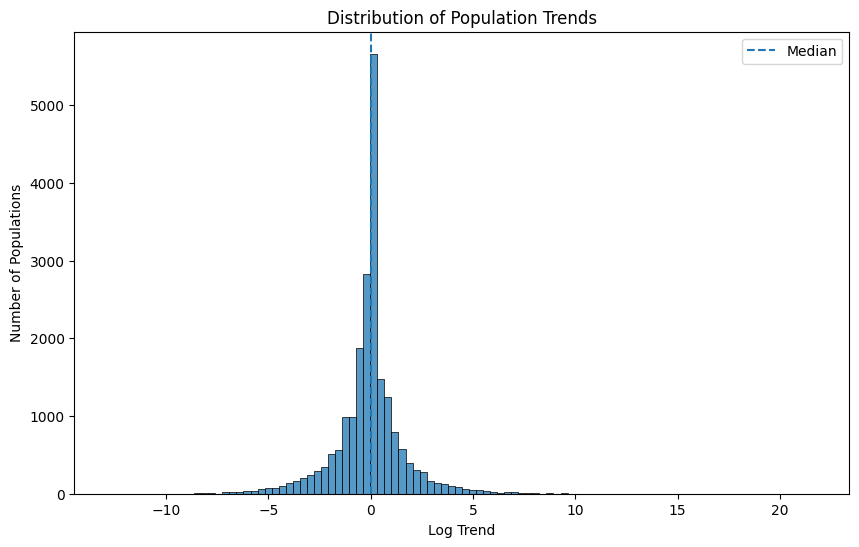

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    trend_data["Log_Trend"],
    bins=100
)

plt.axvline(
    trend_data["Log_Trend"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Population Trends")
plt.xlabel("Log Trend")
plt.ylabel("Number of Populations")
plt.legend()

plt.show()

In [27]:
trend_data["Log_Trend"].quantile(
    [0.05, 0.25, 0.5, 0.75, 0.95]
)

0.05   -3.002530
0.25   -0.690656
0.50    0.000000
0.75    0.464595
0.95    2.544973
Name: Log_Trend, dtype: float64

In [28]:
class_trends = (
    trend_data
    .groupby("Class")
    .agg(
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        Populations=("ID", "count")
    )
    .sort_values("Median_Trend")
)

class_trends

,Mean_Trend,Median_Trend,Populations
Class,,,
Dipneusti,-2.456736,-2.456736,1
Amphibia,-0.634989,-0.270945,205
Elasmobranchii,-0.157711,-0.030893,397
Actinopteri,-0.092210,0.000000,4847
Aves,-0.150820,0.000000,12476
Mammalia,0.127391,0.000000,2957
Reptilia,0.049503,0.000600,373
Myxini,-0.056751,0.003363,19
Holocephali,0.019671,0.020643,4


In [32]:
major_classes = class_trends[
    class_trends["Populations"] >= 100
].copy()

major_classes

,Mean_Trend,Median_Trend,Populations
Class,,,
Amphibia,-0.634989,-0.270945,205
Elasmobranchii,-0.157711,-0.030893,397
Actinopteri,-0.092210,0.000000,4847
Aves,-0.150820,0.000000,12476
Mammalia,0.127391,0.000000,2957
Reptilia,0.049503,0.000600,373


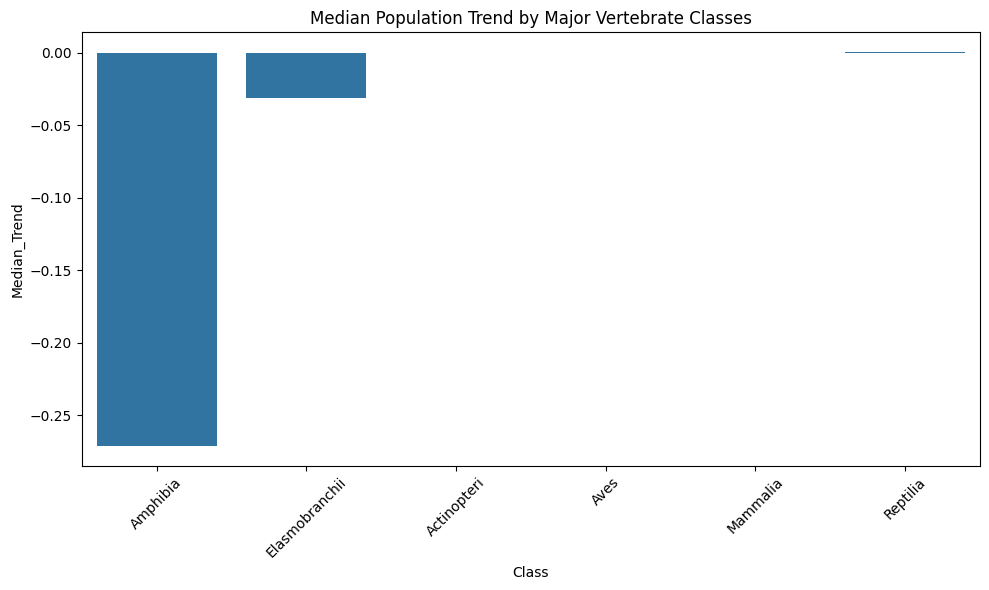

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=major_classes.reset_index(),
    x="Class",
    y="Median_Trend"
)

plt.title("Median Population Trend by Major Vertebrate Classes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
system_trends = (
    trend_data
    .groupby("System")
    .agg(
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        Populations=("ID", "count")
    )
)

system_trends

,Mean_Trend,Median_Trend,Populations
System,,,
Freshwater,0.131691,0.0,4169
Marine,-0.250065,0.0,10186
Terrestrial,-0.018456,0.0,6929


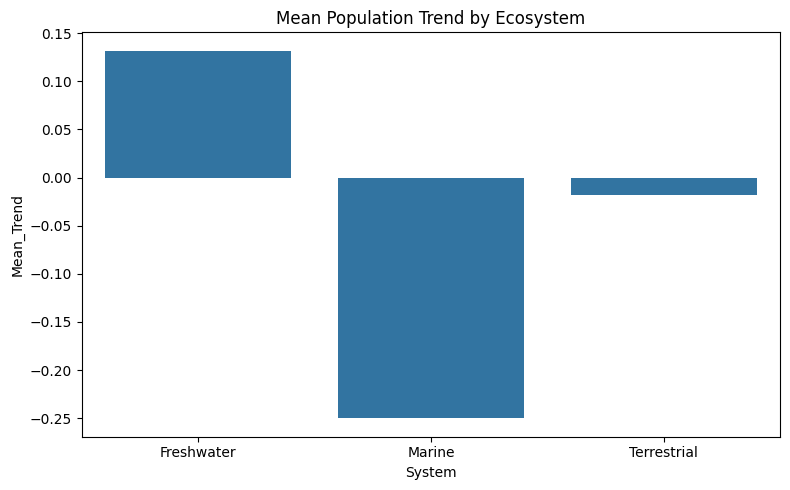

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=system_trends.reset_index(),
    x="System",
    y="Mean_Trend"
)

plt.title("Mean Population Trend by Ecosystem")
plt.tight_layout()
plt.show()

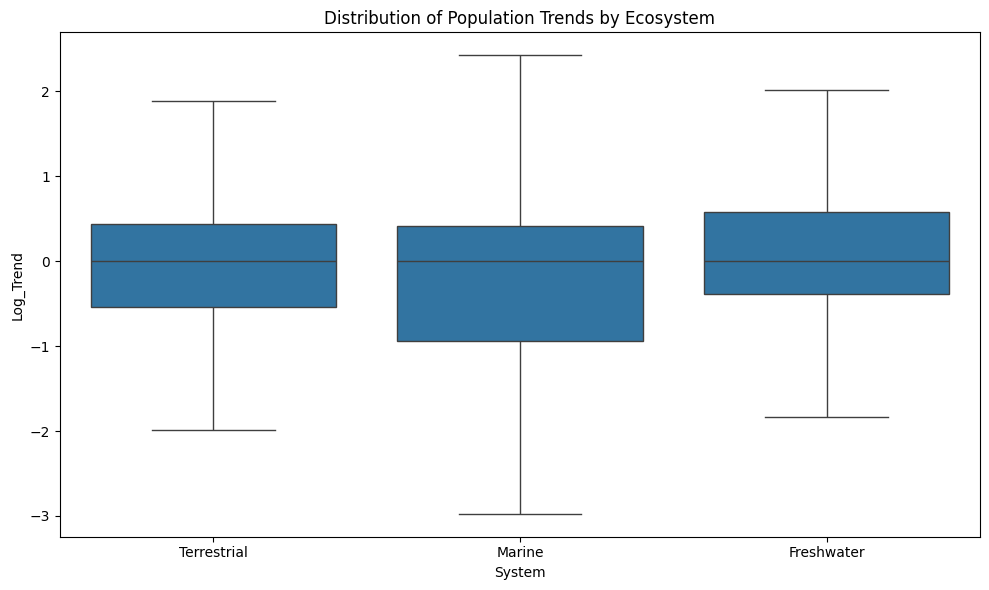

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=trend_data,
    x="System",
    y="Log_Trend",
    showfliers=False
)

plt.title("Distribution of Population Trends by Ecosystem")
plt.tight_layout()
plt.show()

In [37]:
major_classes = class_trends[
    class_trends["Populations"] >= 100
].index.tolist()

major_classes

['Amphibia', 'Elasmobranchii', 'Actinopteri', 'Aves', 'Mammalia', 'Reptilia']

In [38]:
boxplot_data = trend_data[
    trend_data["Class"].isin(major_classes)
].copy()

boxplot_data.shape

(21255, 14)

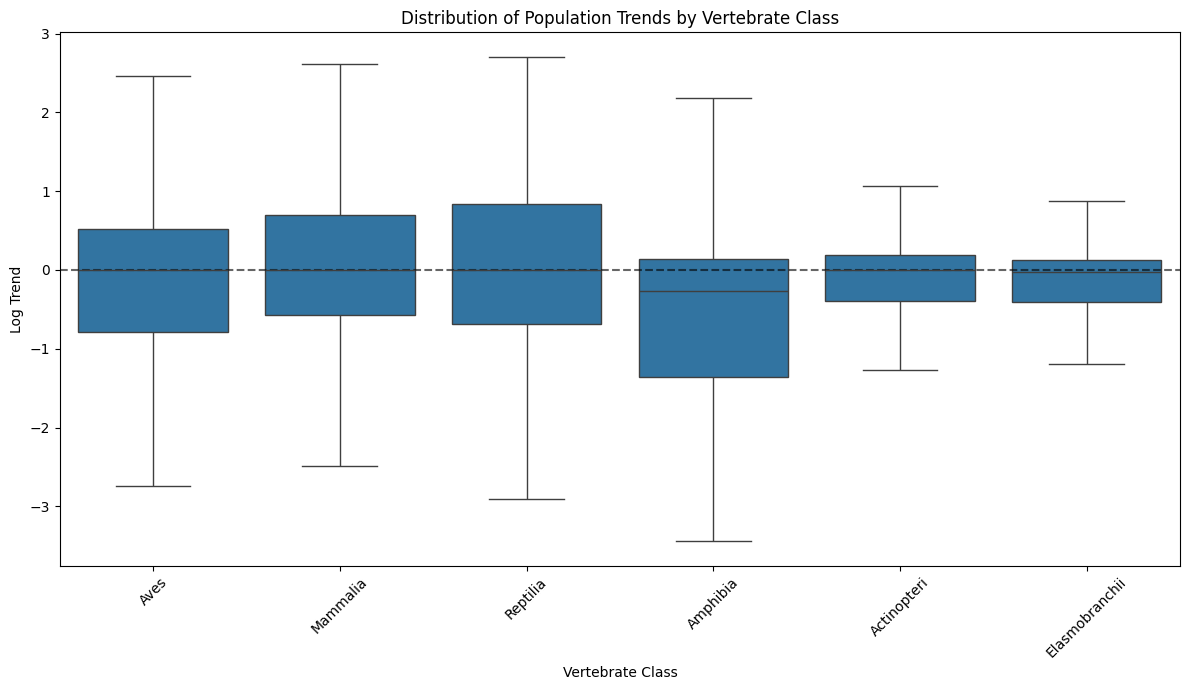

In [39]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=boxplot_data,
    x="Class",
    y="Log_Trend",
    showfliers=False
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Distribution of Population Trends by Vertebrate Class"
)

plt.xlabel("Vertebrate Class")
plt.ylabel("Log Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

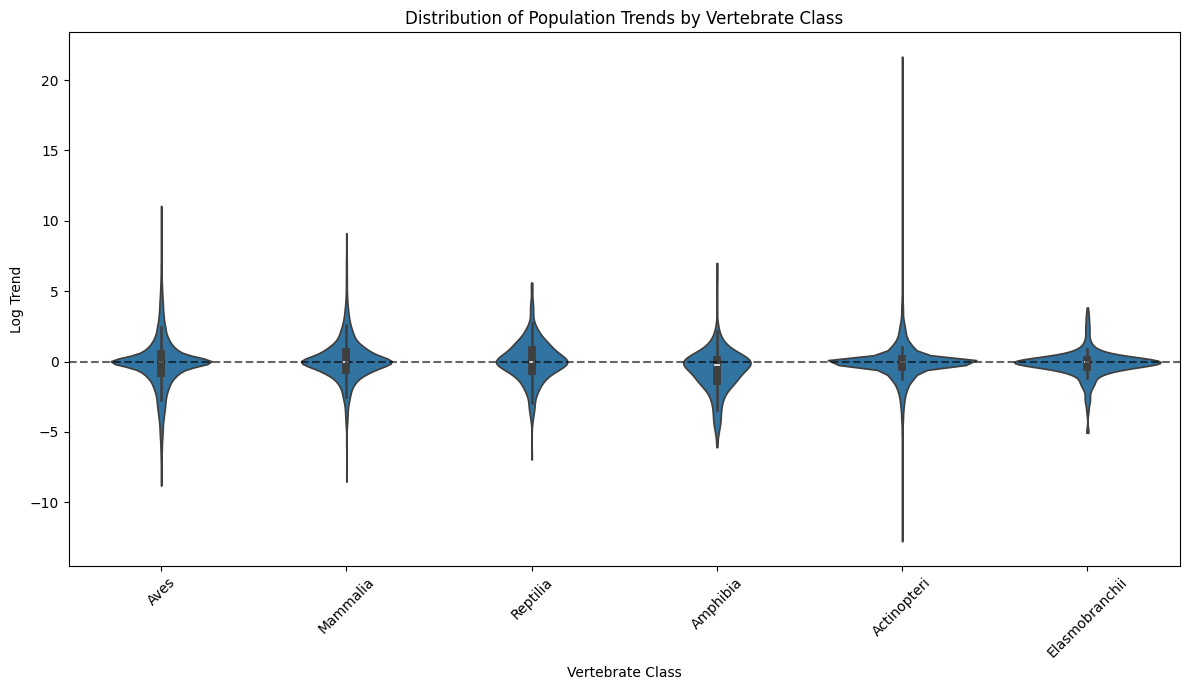

In [40]:
plt.figure(figsize=(12, 7))

sns.violinplot(
    data=boxplot_data,
    x="Class",
    y="Log_Trend",
    cut=0
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Distribution of Population Trends by Vertebrate Class"
)

plt.xlabel("Vertebrate Class")
plt.ylabel("Log Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [41]:
class_summary = (
    boxplot_data
    .groupby("Class")
    .agg(
        Populations=("ID", "count"),
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median"),
        Q25=("Log_Trend", lambda x: x.quantile(0.25)),
        Q75=("Log_Trend", lambda x: x.quantile(0.75))
    )
    .sort_values("Mean_Trend")
)

class_summary.round(3)

,Populations,Mean_Trend,Median_Trend,Q25,Q75
Class,,,,,
Amphibia,205,-0.635,-0.271,-1.354,0.141
Elasmobranchii,397,-0.158,-0.031,-0.405,0.121
Aves,12476,-0.151,0.000,-0.785,0.517
Actinopteri,4847,-0.092,0.000,-0.396,0.187
Reptilia,373,0.050,0.001,-0.683,0.836
Mammalia,2957,0.127,0.000,-0.574,0.702


In [42]:
region_summary = (
    trend_data
    .groupby("Region")
    .agg(
        Populations=("ID", "count"),
        Mean_Trend=("Log_Trend", "mean"),
        Median_Trend=("Log_Trend", "median")
    )
    .sort_values("Mean_Trend")
)

region_summary.round(3)

,Populations,Mean_Trend,Median_Trend
Region,,,
Oceania,6874,-0.467,0.000
International Waters,154,-0.381,-0.284
Africa,1577,-0.208,-0.122
Latin America and Caribbean,2132,-0.099,0.000
Asia,966,-0.074,0.000
North America,5731,-0.026,-0.000
Antarctic,202,0.222,0.253
Europe,3648,0.508,0.240


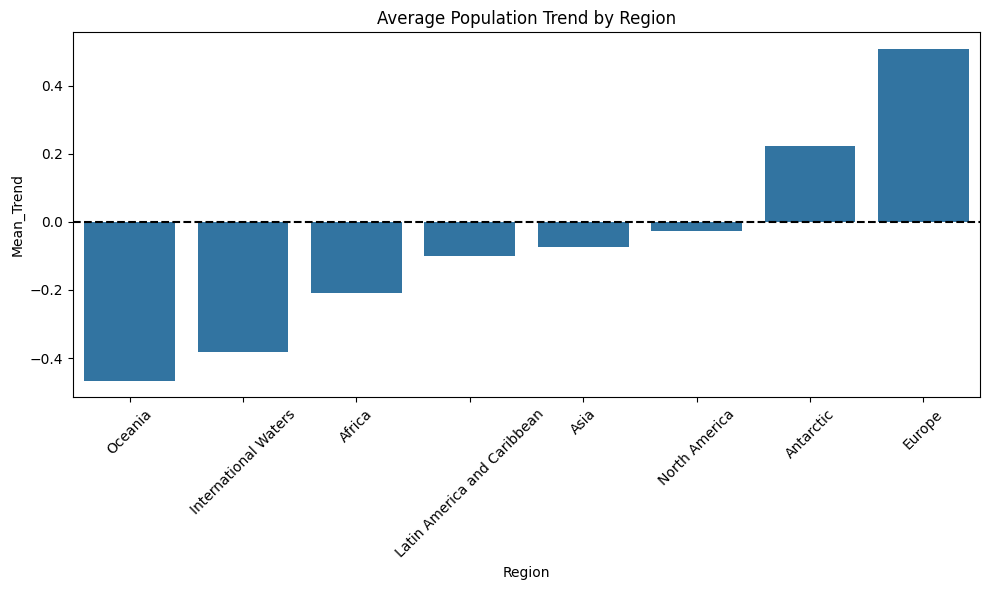

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=region_summary.reset_index(),
    x="Region",
    y="Mean_Trend"
)

plt.axhline(0, color="black", linestyle="--")

plt.xticks(rotation=45)

plt.title("Average Population Trend by Region")

plt.tight_layout()
plt.show()

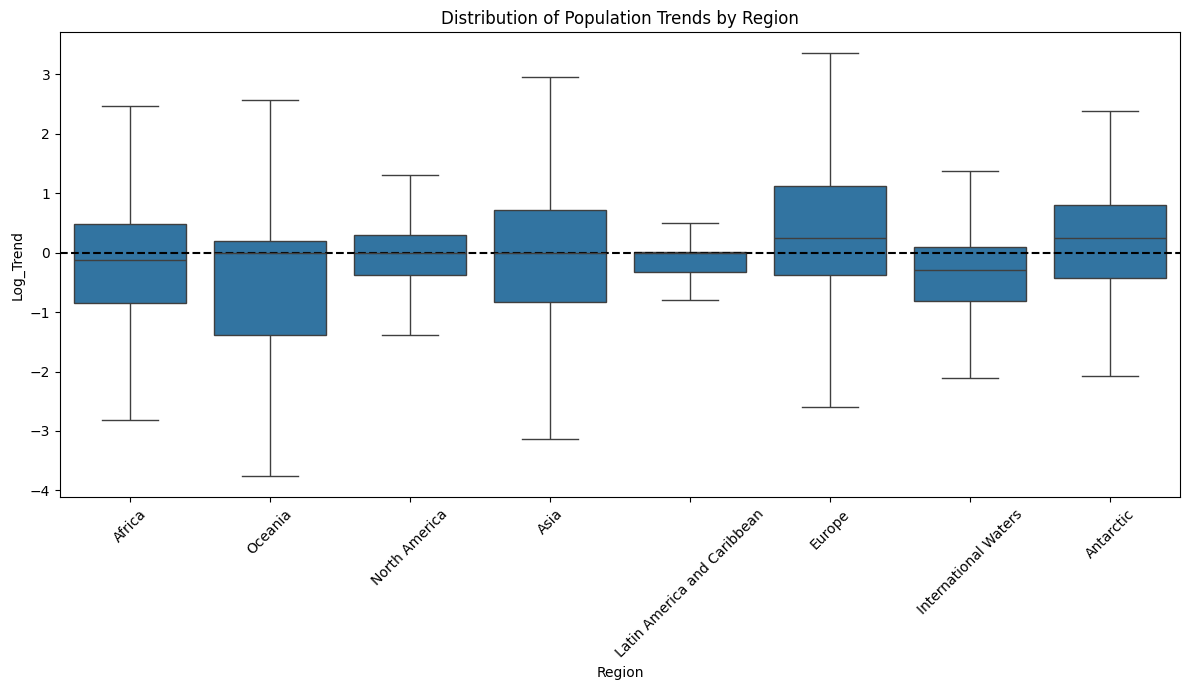

In [44]:
plt.figure(figsize=(12,7))

sns.boxplot(
    data=trend_data,
    x="Region",
    y="Log_Trend",
    showfliers=False
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xticks(rotation=45)

plt.title(
    "Distribution of Population Trends by Region"
)

plt.tight_layout()

plt.show()

In [45]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

trend_data.to_csv(
    processed_dir / "population_trends_lpd_2024.csv",
    index=False
)

print("Saved:", processed_dir / "population_trends_lpd_2024.csv")
print(trend_data.shape)

Saved: ../data/processed/population_trends_lpd_2024.csv
(21284, 14)
